In [1]:
import math
import csv
import matplotlib.pyplot as plt
from numpy.random import uniform

/home/zonzin/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
class Ponto: 
    def __init__(self, x: float, y: float): 
        self.x = x
        self.y = y

    def __str__(self):
        return str((self.x, self.y))


In [ ]:
class Kmeans: 
    def __init__(self, caminho, K = 2, maxIteracoes = 15): 
        self.caminho = caminho
        self.espaco  = []
        self.dimEspaco = None
        self.K       = K
        self.centroides = None
        self.xmin, self.xmax = None, None
        self.xmin, self.ymax = None, None
        self.maxIteracoes = maxIteracoes 

    def determina_limites(self): 
        X, Y = zip(*self.espaco)
        self.xmin, self.xmax = min(X), max(X)
        self.ymin, self.ymax = min(Y), max(Y)
    
    def print_pontos(self):
        for p in self.espaco:
            print(p)

    """
    def plota_espaco(self, save = False):
        plt.figure(figsize=(8, 6))
        X, Y = zip(*self.espaco)
        plt.scatter(X, Y)

        centroidesX, centroidesY = zip(*self.centroides)
        plt.scatter(centroidesX, centroidesY, marker = '^')
        
        plt.show()
        
        if save == True: 
            #plt.savefig()    
            pass
    """
    def plota_espaco(self):
        plt.figure(figsize=(8,6))
    
        for i, grupo in enumerate(self.grupos):
    
            if len(grupo) > 0:
                X, Y = zip(*grupo)
                plt.scatter(X, Y, label=f'Cluster {i}')
    
        centroidesX, centroidesY = zip(*self.centroides)

        plt.scatter(centroidesX, centroidesY, color='black', marker='^', s=200, label='Centroides')
        plt.legend()
        plt.show()
        
    def ler_arquivo(self):
        with open(self.caminho, 'r') as f: 
            reader = csv.reader(f)

            for i, row in enumerate(reader): 
                if i == 0: continue
                x, y = float(row[0]), float(row[1])
                self.espaco.append((x,y))
        
        self.determina_limites()

    def dist_euclidiana(self, p1: tuple, p2: tuple):
        #x = (x0, x1, ..., xn) 
        #y = (y0, y1, ..., yn)
        #d(x,y)**2 = sum{xi - yi}**2
        sum = 0
        for i in range(len(p1)): 
            sum += (p1[i] - p2[i])**2 

        return sum**0.5
        
    def fit(self):
        self.centroides = [(uniform(self.xmin, self.xmax), uniform(self.ymin, self.ymax)) for _ in range(self.K)]
    
        for iteracao in range(self.maxIteracoes):
    
            grupos = [[] for _ in range(self.K)]
    
            for ponto in self.espaco:    
                distancias = [self.dist_euclidiana(ponto, centroide) for centroide in self.centroides]
    
                indice_centroide = distancias.index(min(distancias))
                grupos[indice_centroide].append(ponto)
    
            centroides_antigos = self.centroides.copy()
    
            novos_centroides = []
    
            for grupo in grupos:
    
                if len(grupo) == 0:
                    novo_centroide = (
                        uniform(self.xmin, self.xmax),
                        uniform(self.ymin, self.ymax)
                    )
    
                else:
                    x_med = sum(p[0] for p in grupo) / len(grupo)
                    y_med = sum(p[1] for p in grupo) / len(grupo)
    
                    novo_centroide = (x_med, y_med)
    
                novos_centroides.append(novo_centroide)
    
            self.centroides = novos_centroides
    
            convergiu = True
    
            for antigo, novo in zip(centroides_antigos, self.centroides):
                if self.dist_euclidiana(antigo, novo) > 1e-6:
                    convergiu = False
                    break
    
            if convergiu:
                print(f"Convergiu na iteração {iteracao + 1}")
                break
    
        self.grupos = grupos
    
    """
    def fit(self):
        self.centroides = [(uniform(self.xmin, self.xmax), uniform(self.ymin, self.ymax)) for _ in range(self.K)]

        for ponto in self.espaco: 
            for centroide in self.centroides:
                print(ponto, centroide, self.dist_euclidiana(ponto, centroide))
    """


                
            
    

Convergiu na iteração 2


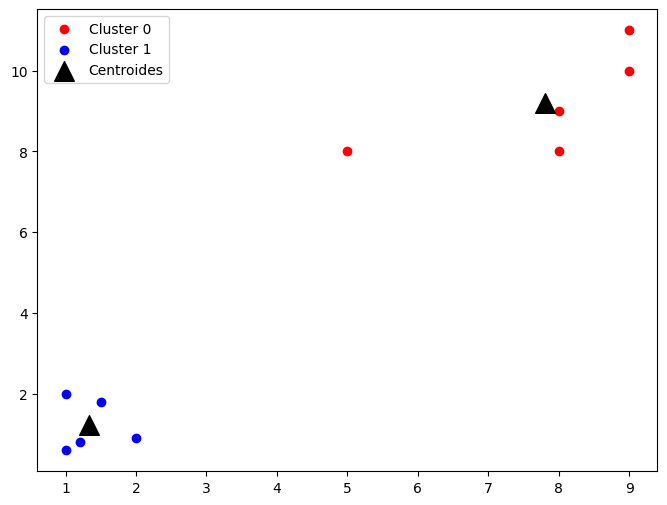

In [7]:
meuKmeans = Kmeans(caminho='dados_1_simples.csv')
meuKmeans.ler_arquivo()
#meuKmeans.print_pontos()

meuKmeans.fit()
meuKmeans.plota_espaco()
#print(meuKmeans.espaco[0], meuKmeans.espaco[2])
#print(meuKmeans.dist_euclidiana(meuKmeans.espaco[0], meuKmeans.espaco[2]))